CH.SC.U4CSE24111-DARUNKUMAR J

K Means Clustering Exercise-2

Saving sample image.webp to sample image.webp
Original Image Shape: (396, 396, 3)
Pixel Data Shape: (156816, 3)


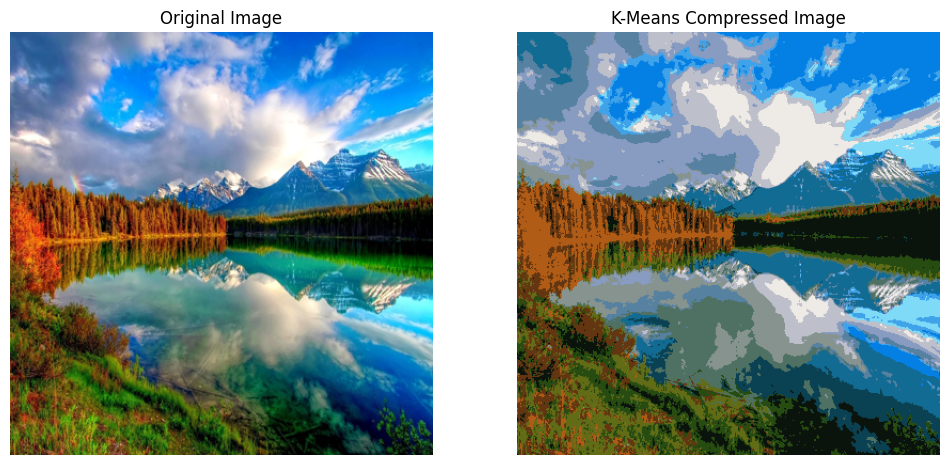

Image compression completed!
Original image shape: (396, 396, 3)
Compressed image shape: (396, 396, 3)
Number of colors used: 16
Compressed image saved as: compressed_image.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image
from google.colab import files

# Upload image
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Open image
image = Image.open(image_path)

# Resize image to 396 x 396
image = image.resize((396, 396))

# Convert image to RGB
image = image.convert("RGB")

# Convert image to NumPy array
image_array = np.array(image)

print("Original Image Shape:", image_array.shape)

# Reshape image into pixels
pixels = image_array.reshape(-1, 3)

print("Pixel Data Shape:", pixels.shape)

# Number of colors
k = 16

# Apply K-Means
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans.fit(pixels)

# Get cluster centers and labels
colors = kmeans.cluster_centers_
labels = kmeans.labels_

# Replace pixels with cluster-center colors
compressed_pixels = colors[labels]

# Convert to RGB values
compressed_pixels = np.clip(
    compressed_pixels.astype(np.uint8),
    0,
    255
)

# Reshape back into image
compressed_image = compressed_pixels.reshape(396, 396, 3)

# Display images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(compressed_image)
plt.title("K-Means Compressed Image")
plt.axis("off")

plt.show()

# Save compressed image
output_image = Image.fromarray(compressed_image)
output_image.save("compressed_image.png")

print("Image compression completed!")
print("Original image shape:", image_array.shape)
print("Compressed image shape:", compressed_image.shape)
print("Number of colors used:", k)
print("Compressed image saved as: compressed_image.png")

# Download compressed image
files.download("compressed_image.png")